In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.stats import spearmanr
from scipy.stats import linregress


plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 14, 'font.family':'Arial'})

### Get all VMGC species with at least 5 genomes per species

In [2]:
df = pd.read_csv('VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_MAG.info', sep='\t')
sgb_info = pd.read_csv('VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_SGB.info', sep='\t', index_col=0)
sgb_to_species = sgb_info['Species']
df['species'] = df['Species-level_genomic_bin_(95%_ANI)'].map(sgb_to_species)

In [3]:

#dictionary of species name to species ID code
genome_to_sgb = pd.read_csv('VMGC_db_build/genomes_and_SGBs.csv')
vmgc_species_to_id = genome_to_sgb.drop_duplicates(['species_name','species']).set_index('species_name')['species'].to_dict()

In [4]:
#count genomes per species
vmgc_species_counts = df.value_counts('species')

In [5]:
sp_to_keep = vmgc_species_counts[vmgc_species_counts >= 5].index.tolist()

In [6]:
len(sp_to_keep)

179

In [7]:
vmgc_species_counts.loc[sp_to_keep].describe()

count     179.000000
mean      105.977654
std       212.018521
min         5.000000
25%         7.000000
50%        19.000000
75%        93.500000
max      1876.000000
Name: count, dtype: float64

In [8]:
vmgc_species_counts.loc[sp_to_keep].median()

19.0

### Get taxonomic counts

In [9]:
vmgc_species_counts_filt = vmgc_species_counts.loc[sp_to_keep]

In [10]:
to_merge = sgb_info[['Family', 'Genus', 'Species']].drop_duplicates().set_index('Species')
tax_info = vmgc_species_counts_filt.to_frame().merge(to_merge, left_index=True, right_index=True, how='left')

In [11]:
tax_info['Family'].nunique(), tax_info['Genus'].nunique()

(42, 81)

In [12]:
tax_info['Family'].value_counts(normalize=True)

Family
Peptoniphilaceae           0.128492
Bacteroidaceae             0.094972
Bifidobacteriaceae         0.094972
Mycobacteriaceae           0.078212
Lactobacillaceae           0.078212
Actinomycetaceae           0.055866
Porphyromonadaceae         0.044693
Lachnospiraceae            0.039106
Streptococcaceae           0.033520
Fastidiosipilaceae         0.027933
Atopobiaceae               0.027933
Staphylococcaceae          0.022346
Enterobacteriaceae         0.022346
Dialisteraceae             0.016760
Eggerthellaceae            0.016760
Mycoplasmoidaceae          0.016760
Campylobacteraceae         0.011173
Enterococcaceae            0.011173
Fusobacteriaceae           0.011173
Veillonellaceae            0.011173
Neisseriaceae              0.011173
Peptostreptococcaceae      0.011173
Nanoperiomorbaceae         0.011173
Megasphaeraceae            0.011173
Aerococcaceae              0.011173
Leptotrichiaceae           0.011173
Metamycoplasmataceae       0.005587
Gemellaceae          

In [13]:
tax_info['Genus'].value_counts(normalize=True)

Genus
Bifidobacterium    0.089385
Prevotella         0.083799
Corynebacterium    0.072626
Lactobacillus      0.044693
Streptococcus      0.033520
                     ...   
Catonella          0.005587
Fenollaria         0.005587
Oligella           0.005587
Eubacterium_I      0.005587
Haemophilus_D      0.005587
Name: proportion, Length: 81, dtype: float64

### Get quality info

In [14]:
df[df['species'].isin(sp_to_keep)]['Genome_quality'].value_counts(normalize=True)

Genome_quality
medium-quality    0.520348
high-quality      0.431207
near-complete     0.048445
Name: proportion, dtype: float64

### Get pangenome size for these species

In [15]:
pangenome_counts = []
cluster_levels = [75, 80, 85, 90, 95, 99]

for sp in sp_to_keep:

    v = vmgc_species_to_id[sp]
    cluster_path = f'VMGC_db/pangenomes/{v}/clusters_99_info.tsv'
    if not os.path.exists(cluster_path):
        print(v)
        continue

    vmgc_clusters = pd.read_csv(cluster_path, sep='\t')   

    for c in cluster_levels:
        
        vmgc_count = vmgc_clusters[f'centroid_{c}'].unique().shape[0]
        
        pangenome_counts += [[sp, v, c, vmgc_count,]]


/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16220/2999872017.py:12: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  vmgc_clusters = pd.read_csv(cluster_path, sep='\t')


In [16]:
pangenome_counts = pd.DataFrame(pangenome_counts)
pangenome_counts.columns = ['species_name', 'VMGC_species_code', 'cluster_level', 'VMGC_pangenome_size']
pangenome_counts['num_genomes'] = pangenome_counts['species_name'].map(vmgc_species_counts)

pangenome_counts.to_csv('VMGC_pangenome_counts_min_5_genomes.csv', index=False)

In [17]:
pangenome_counts = pd.read_csv('VMGC_pangenome_counts_min_5_genomes.csv')
pangenome_counts

,species_name,VMGC_species_code,cluster_level,VMGC_pangenome_size,num_genomes
0,Lactobacillus iners,240891,75,5545,1876
1,Lactobacillus iners,240891,80,5742,1876
2,Lactobacillus iners,240891,85,6016,1876
3,Lactobacillus iners,240891,90,6602,1876
4,Lactobacillus iners,240891,95,8443,1876
...,...,...,...,...,...
1069,Porphyromonas pasteri,239478,80,2045,5
1070,Porphyromonas pasteri,239478,85,2075,5
1071,Porphyromonas pasteri,239478,90,2149,5
1072,Porphyromonas pasteri,239478,95,2761,5


In [18]:
pangenome_counts[pangenome_counts['cluster_level'] == 90]['VMGC_pangenome_size'].describe()

count      179.000000
mean      3799.413408
std       2447.976327
min        713.000000
25%       2358.000000
50%       3248.000000
75%       4409.500000
max      18533.000000
Name: VMGC_pangenome_size, dtype: float64

### Plotting

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16220/2776542675.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_num_genomes'] = np.log10(temp['num_genomes'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16220/2776542675.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])


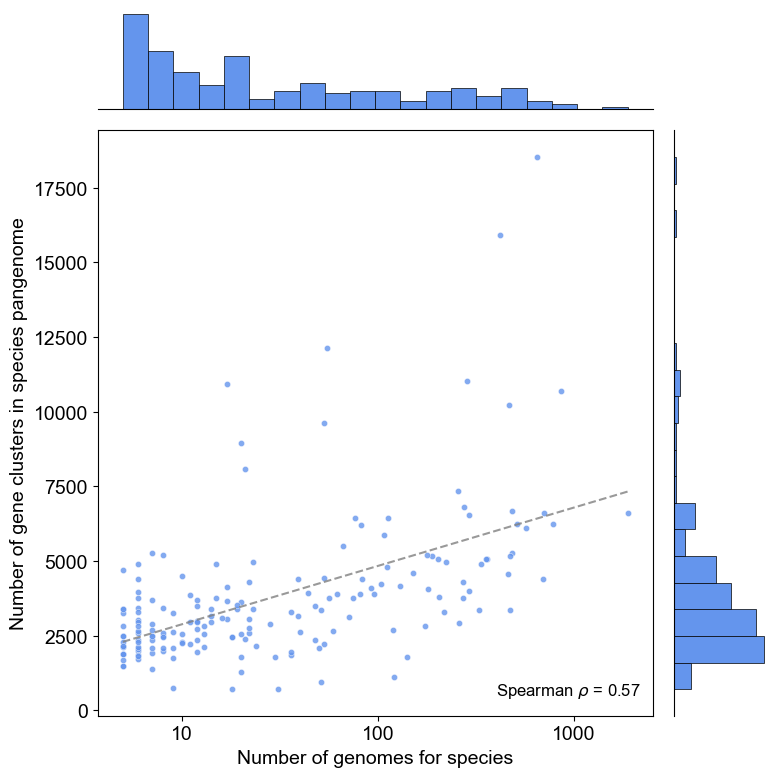

In [26]:
c = 90
    
temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
temp['log_num_genomes'] = np.log10(temp['num_genomes'])
temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])


# Square plot (4x4 inches)
g = sns.JointGrid(
    x="log_num_genomes",
    y="VMGC_pangenome_size",
    data=temp,
    height=8,
    ratio=5
)

# Scatterplot with size and alpha
g.plot_joint(sns.scatterplot, s=20, alpha=0.8,
             color='cornflowerblue')

# Marginal histograms
g.ax_marg_x.hist(temp['log_num_genomes'], 
                    bins=20,
                linewidth=0.5, edgecolor='black', color='cornflowerblue')
g.ax_marg_y.hist(temp['VMGC_pangenome_size'], 
                    bins=20, color='cornflowerblue',
                    orientation='horizontal', linewidth=0.5, edgecolor='black')

g.ax_marg_x.set_xticks([1,2,3], [10,100,1000])
# g.ax_marg_y.set_yticks([3,np.log10(5000),4], [10**3,5000,10**4])

# Remove ticks and spines on marginal histograms
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)
# sns.despine(ax=g.ax_marg_x, bottom=True, left=True)
# sns.despine(ax=g.ax_marg_y, bottom=True, left=True)

sns.despine(ax=g.ax_joint, top=False, right=False)


x = temp['log_num_genomes']
y = temp['VMGC_pangenome_size']

slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
regression_line = slope * x + intercept

# Plot the regression line
g.ax_joint.plot(x, regression_line, color='gray', linestyle='--', alpha=0.8)

correlation_coefficient, p_value = spearmanr(x, y)
g.ax_joint.annotate('Spearman ' + r'$\rho$' + f' = {round(correlation_coefficient,2)}',
                    xy=(2.6,500), fontsize=12)

g.ax_joint.set_xlabel('Number of genomes for species')
g.ax_joint.set_ylabel(f'Number of gene clusters in species pangenome')
fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_1B.png', format='png', dpi=600, bbox_inches="tight")

plt.tight_layout()

In [27]:
for c in [99, 95, 90, 85, 80, 75]:   

    temp = pangenome_counts[pangenome_counts['cluster_level'] == c]

    q = temp['VMGC_pangenome_size'].quantile([0.25, 0.75])


    print(f"Number of {c}% ANI gene clusters in pangenome:")
    print(f"median: {round(temp['VMGC_pangenome_size'].median())}, range: {temp['VMGC_pangenome_size'].min()}-{temp['VMGC_pangenome_size'].max()},  IQR: {round(q.loc[0.25])}-{round(q.loc[0.75])}")

Number of 99% ANI gene clusters in pangenome:
median: 7447, range: 881-162848,  IQR: 4223-14206
Number of 95% ANI gene clusters in pangenome:
median: 3626, range: 740-24294,  IQR: 2643-5351
Number of 90% ANI gene clusters in pangenome:
median: 3248, range: 713-18533,  IQR: 2358-4410
Number of 85% ANI gene clusters in pangenome:
median: 3081, range: 699-16818,  IQR: 2304-4091
Number of 80% ANI gene clusters in pangenome:
median: 2951, range: 691-15942,  IQR: 2274-3840
Number of 75% ANI gene clusters in pangenome:
median: 2907, range: 681-15379,  IQR: 2258-3728


In [28]:
temp['VMGC_pangenome_size'].quantile([0.25, 0.75])

0.25    2258.0
0.75    3727.5
Name: VMGC_pangenome_size, dtype: float64

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16220/582938726.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_num_genomes'] = np.log10(temp['num_genomes'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16220/582938726.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16220/582938726.py:4: SettingWithCopyWarning: 
A value is trying to be 

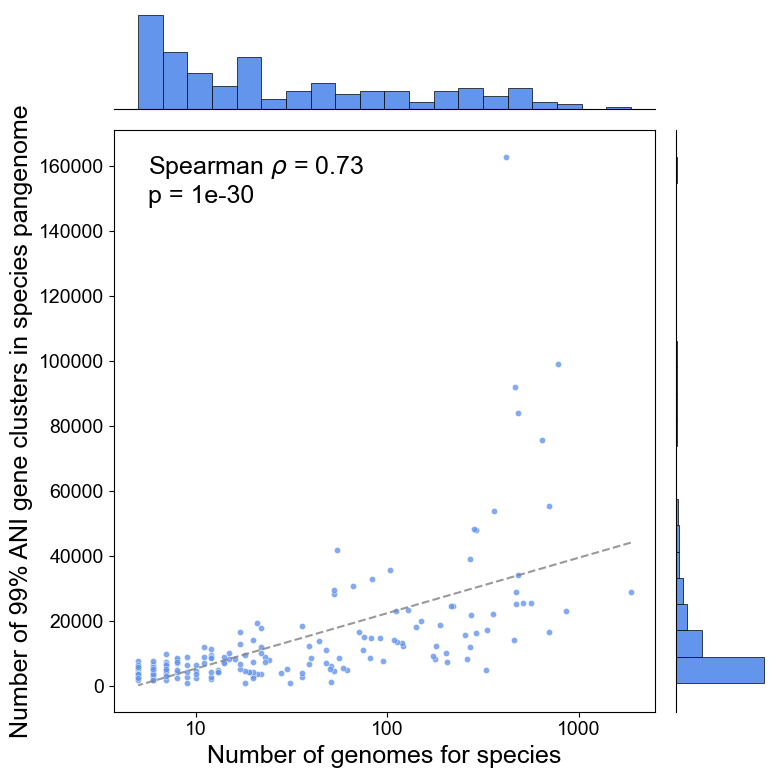

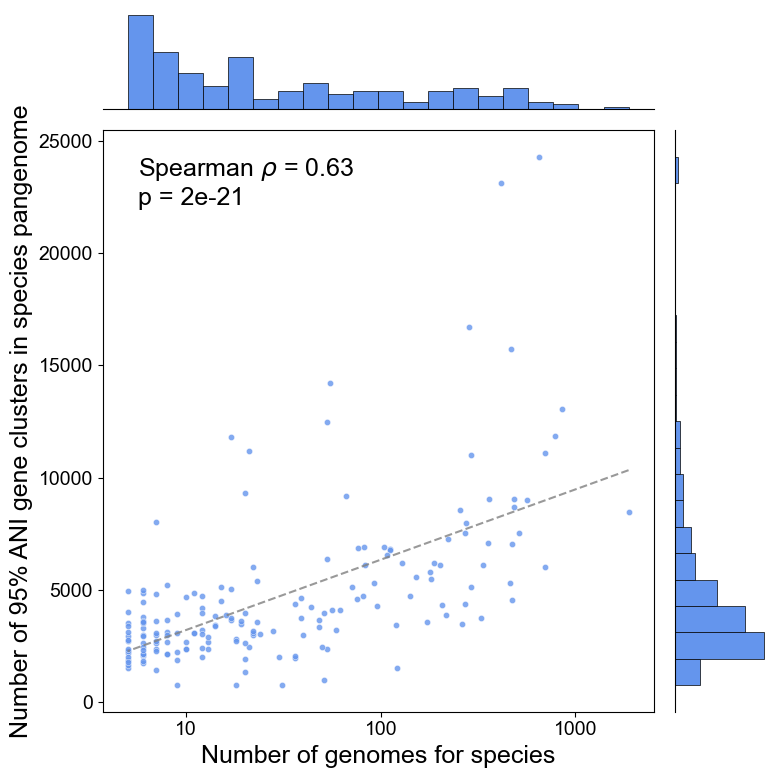

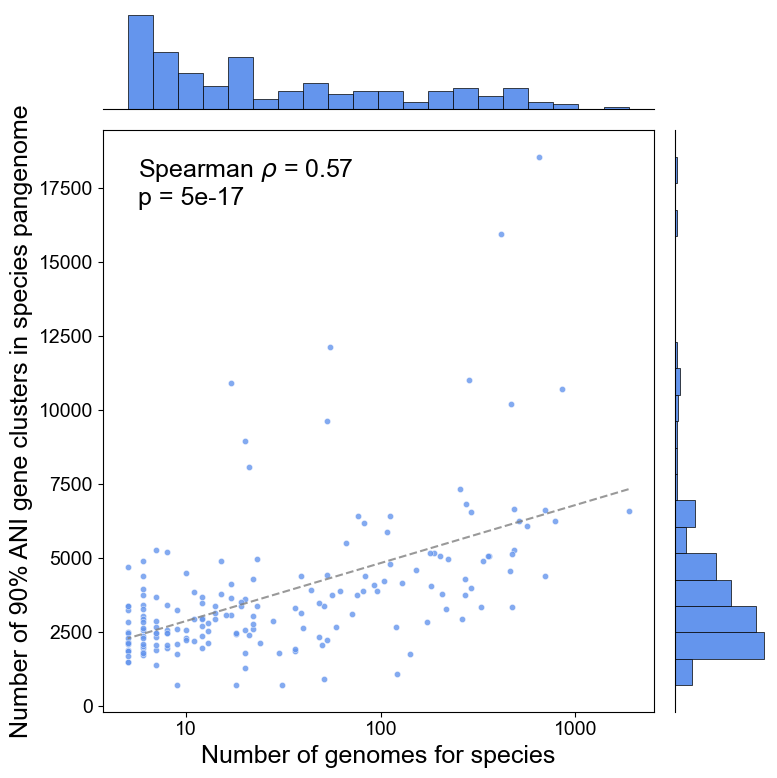

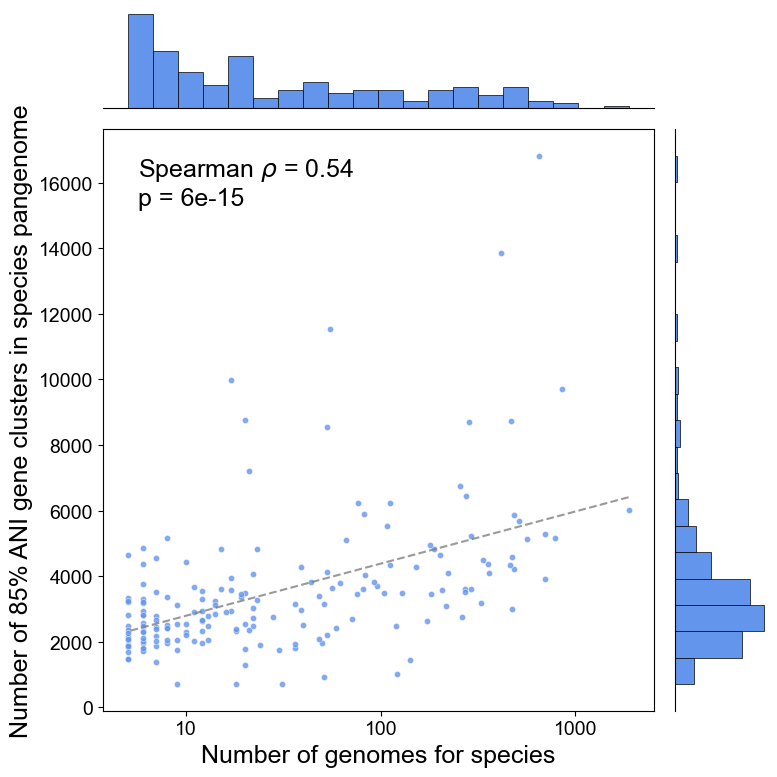

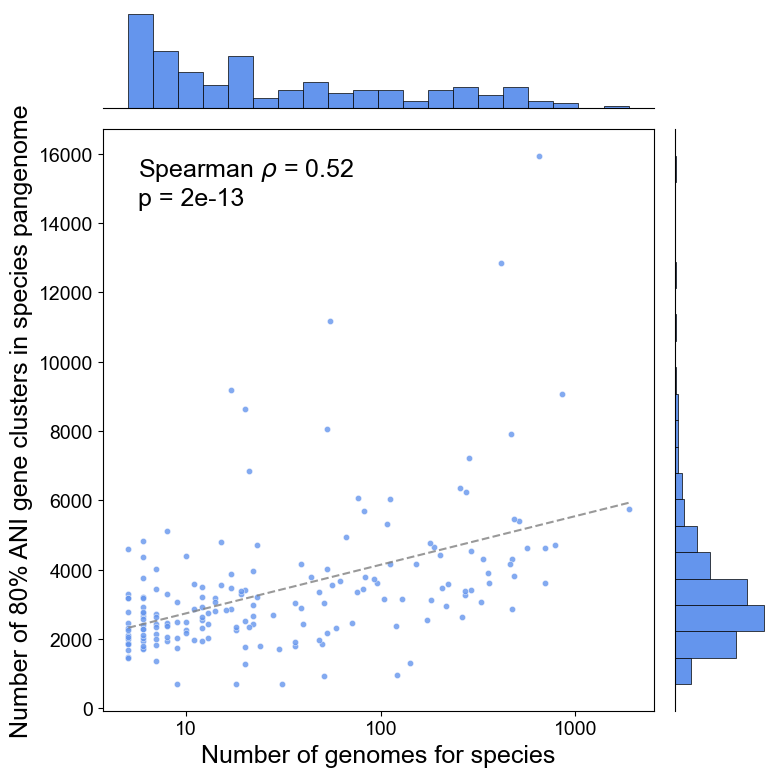

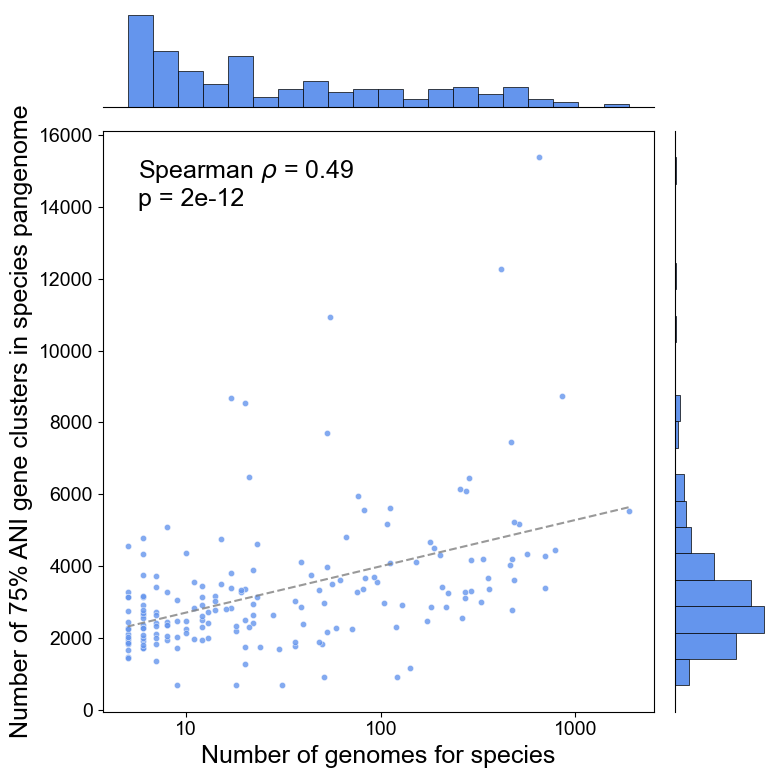

In [29]:
for c in [99, 95, 90, 85, 80, 75]:   

    temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
    temp['log_num_genomes'] = np.log10(temp['num_genomes'])
    temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])

    # Square plot (4x4 inches)
    g = sns.JointGrid(
        x="log_num_genomes",
        y="VMGC_pangenome_size",
        data=temp,
        height=8,
        ratio=5
    )

    # Scatterplot with size and alpha
    g.plot_joint(sns.scatterplot, s=20, alpha=0.8,
                color='cornflowerblue')

    # Marginal histograms
    g.ax_marg_x.hist(temp['log_num_genomes'], 
                        bins=20,
                    linewidth=0.5, edgecolor='black', color='cornflowerblue')
    g.ax_marg_y.hist(temp['VMGC_pangenome_size'], 
                        bins=20, color='cornflowerblue',
                        orientation='horizontal', linewidth=0.5, edgecolor='black')

    g.ax_marg_x.set_xticks([1,2,3], [10,100,1000])
    # g.ax_marg_y.set_yticks([3,np.log10(5000),4], [10**3,5000,10**4])

    # Remove ticks and spines on marginal histograms
    g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
    g.ax_marg_y.tick_params(left=False, labelleft=False)
    # sns.despine(ax=g.ax_marg_x, bottom=True, left=True)
    # sns.despine(ax=g.ax_marg_y, bottom=True, left=True)

    sns.despine(ax=g.ax_joint, top=False, right=False)


    x = temp['log_num_genomes']
    y = temp['VMGC_pangenome_size']

    slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
    regression_line = slope * x + intercept

    # Plot the regression line
    g.ax_joint.plot(x, regression_line, color='gray', linestyle='--', alpha=0.8)

    correlation_coefficient, p_value = spearmanr(x, y)

    # to_annotate = 'Spearman ' + r'$\rho$' + f' = {round(correlation_coefficient,2)}'

    # to_annotate += '$\n \it{p}}$' 
    # to_annotate += f'{"{:.0e}".format(p_value)}'

    # g.ax_joint.annotate(to_annotate,
    #                     xy=(2.6,500), fontsize=12)
    to_annotate = f'Spearman $\\rho$ = {round(correlation_coefficient, 2)}\n'
    # to_annotate += f'$\\mathit{{p}}$ = {p_value:.0e}'
    to_annotate += f'p = {p_value:.0e}'

    g.ax_joint.annotate(to_annotate, xy=(.75, g.ax_joint.get_ylim()[1]*0.87), fontsize=18, horizontalalignment='left')
    g.ax_joint.tick_params(axis='y', which='major', labelsize=14)

    g.ax_joint.set_xlabel('Number of genomes for species', fontsize=18)
    g.ax_joint.set_ylabel(f'Number of {c}% ANI gene clusters in species pangenome', fontsize=18)
    # plt.savefig(f'/Users/cdubin/Desktop/pangenome_size_{c}.png', format='png', dpi=600, bbox_inches="tight")

    plt.tight_layout()